# Skill Mapping EDA
Exploratory Data Analysis of technology job postings and their required skills.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load & Inspect

In [3]:
df = pd.read_csv('../dataset/cleaned_data/skill_mapping_output.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (10000, 10)


,row_index,title,cleaned_text,skills_technical,skills_soft,skills_tool,skills_domain,skills_certification,all_skills,skill_count
0,0,10 + Blockchain Nodes / Masternodes to set up,blockchain nodes masternodes set requirements ...,blockchain; Kyber Network; Nebulas; SecretNetw...,NaN,NaN,crypto,NaN,blockchain; crypto; Kyber Network; Nebulas; Se...,16
1,1,10 .NET Developers (Middle and Senior level),net developers middle senior level greetings n...,.NET; microservices; multi-cloud; SaaS,NaN,NaN,NaN,NaN,.NET; microservices; multi-cloud; SaaS,4
2,2,"10X Engineer (co-founder, #4 employee, USD 11-...",x engineer co founder employee usd k equity pr...,live video chat; co-browsing,NaN,NaN,NaN,NaN,live video chat; co-browsing,2


In [4]:
df.dtypes

row_index               int64
title                     str
cleaned_text              str
skills_technical          str
skills_soft               str
skills_tool               str
skills_domain             str
skills_certification      str
all_skills                str
skill_count             int64
dtype: object

In [5]:
# Missing values
missing = df.isnull().sum().rename('missing').to_frame()
missing['pct'] = (missing['missing'] / len(df) * 100).round(1)
missing

,missing,pct
row_index,0,0.0
title,0,0.0
cleaned_text,0,0.0
skills_technical,3040,30.4
skills_soft,9070,90.7
skills_tool,8657,86.6
skills_domain,7351,73.5
skills_certification,9935,99.4
all_skills,1342,13.4
skill_count,0,0.0


In [6]:
df['skill_count'].describe()

count    10000.000000
mean         2.657200
std          2.594795
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         28.000000
Name: skill_count, dtype: float64

## 2. Helper — parse semicolon-separated skill columns

In [7]:
def parse_skills(series):
    """Flatten a semicolon-separated skill column into a Counter."""
    counter = Counter()
    for cell in series.dropna():
        for sk in str(cell).split(';'):
            sk = sk.strip().lower()
            if sk:
                counter[sk] += 1
    return counter

all_skills_counter   = parse_skills(df['all_skills'])
tech_counter         = parse_skills(df['skills_technical'])
soft_counter         = parse_skills(df['skills_soft'])
tool_counter         = parse_skills(df['skills_tool'])
domain_counter       = parse_skills(df['skills_domain'])

print(f'Unique skills (all_skills): {len(all_skills_counter)}')
print(f'Unique technical skills:    {len(tech_counter)}')
print(f'Unique soft skills:         {len(soft_counter)}')
print(f'Unique tools:               {len(tool_counter)}')
print(f'Unique domain skills:       {len(domain_counter)}')

Unique skills (all_skills): 5012
Unique technical skills:    2858
Unique soft skills:         285
Unique tools:               683
Unique domain skills:       1634


## 3. Q1 — Most Frequently Required Skills

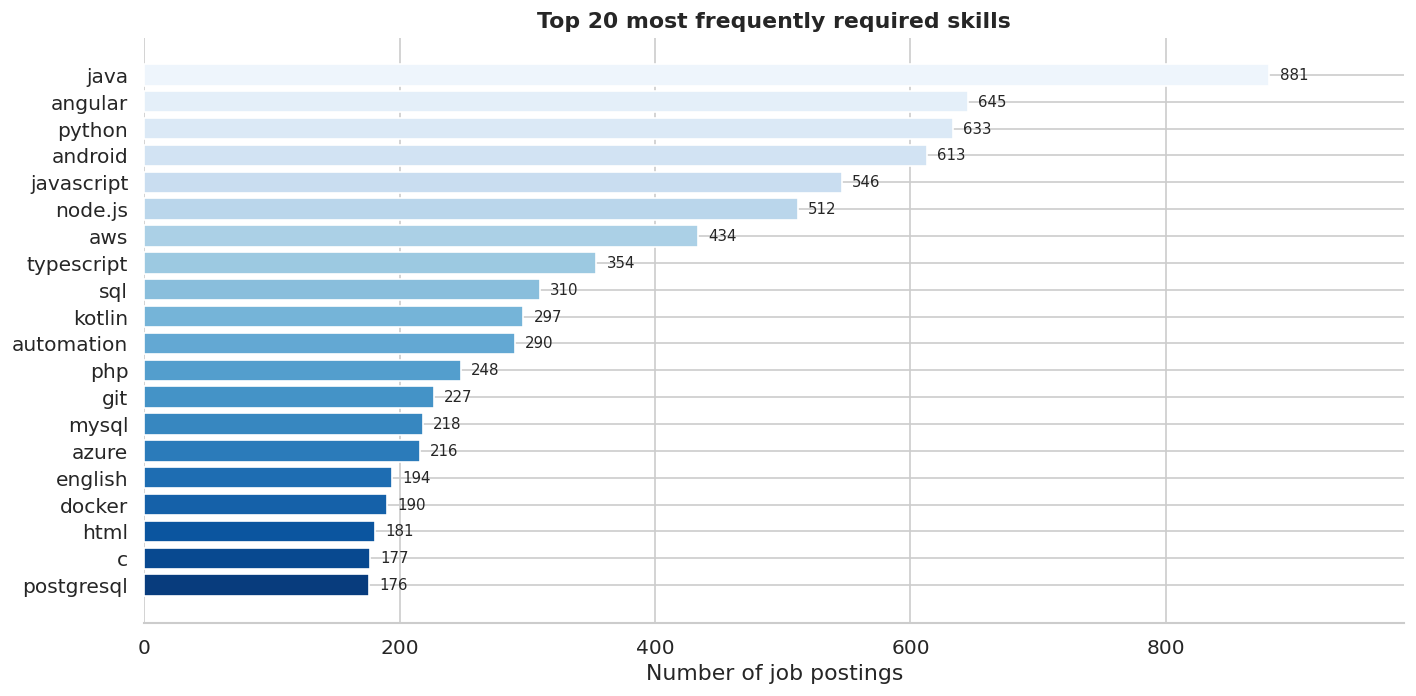

In [8]:
# ── Top 20 overall skills ──
top20 = pd.DataFrame(all_skills_counter.most_common(20), columns=['skill', 'count'])

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('Blues_r', n_colors=20)
bars = ax.barh(top20['skill'][::-1], top20['count'][::-1], color=palette)
for bar, val in zip(bars, top20['count'][::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Number of job postings')
ax.set_title('Top 20 most frequently required skills', fontweight='bold')
ax.set_xlim(0, top20['count'].max() * 1.12)
sns.despine(left=True)
plt.tight_layout()
plt.show()

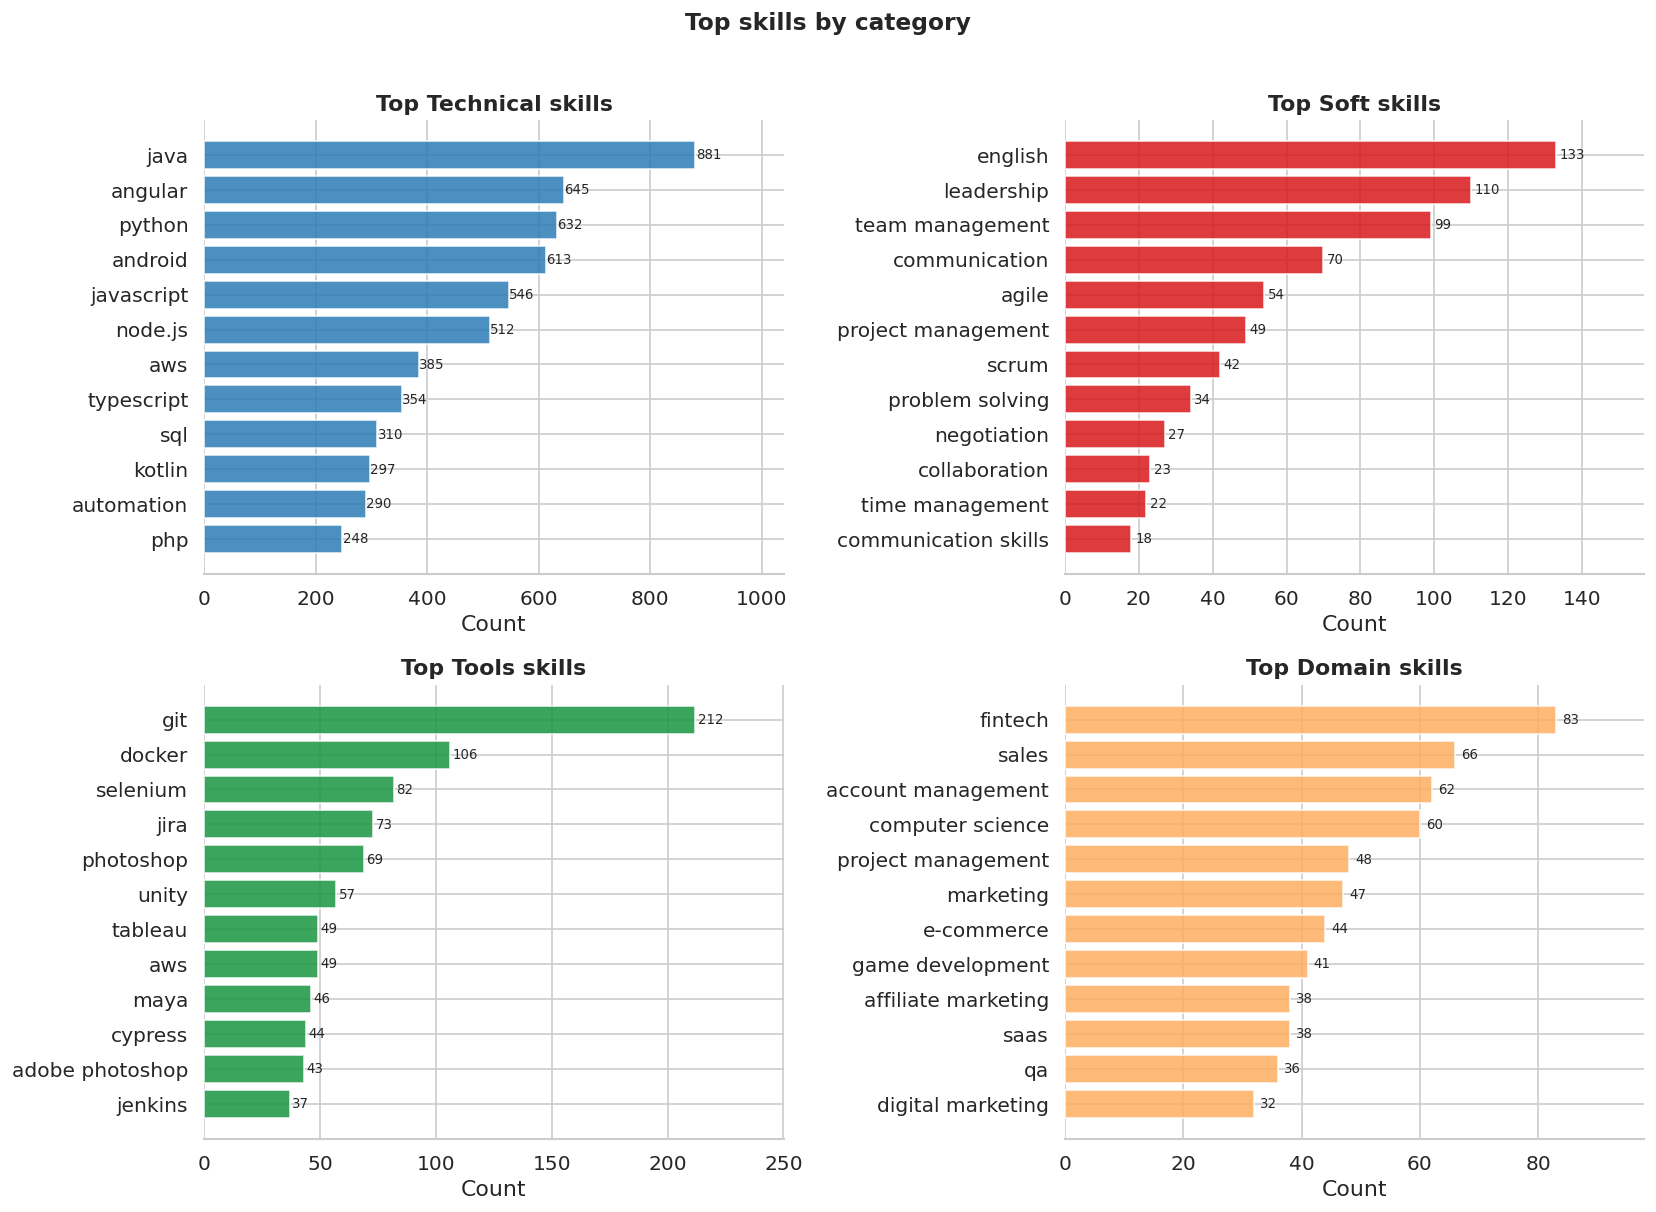

In [9]:
# ── Top 15 per category side-by-side ──
categories = {
    'Technical': tech_counter,
    'Soft': soft_counter,
    'Tools': tool_counter,
    'Domain': domain_counter,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
colors = ['#2c7bb6', '#d7191c', '#1a9641', '#fdae61']

for ax, (cat, counter), color in zip(axes, categories.items(), colors):
    top = pd.DataFrame(counter.most_common(12), columns=['skill', 'count'])
    ax.barh(top['skill'][::-1], top['count'][::-1], color=color, alpha=0.85)
    for i, (_, row) in enumerate(top[::-1].iterrows()):
        ax.text(row['count'] + 1, i, f"{row['count']:,}", va='center', fontsize=8)
    ax.set_title(f'Top {cat} skills', fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_xlim(0, top['count'].max() * 1.18)
    sns.despine(ax=ax, left=True)

plt.suptitle('Top skills by category', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

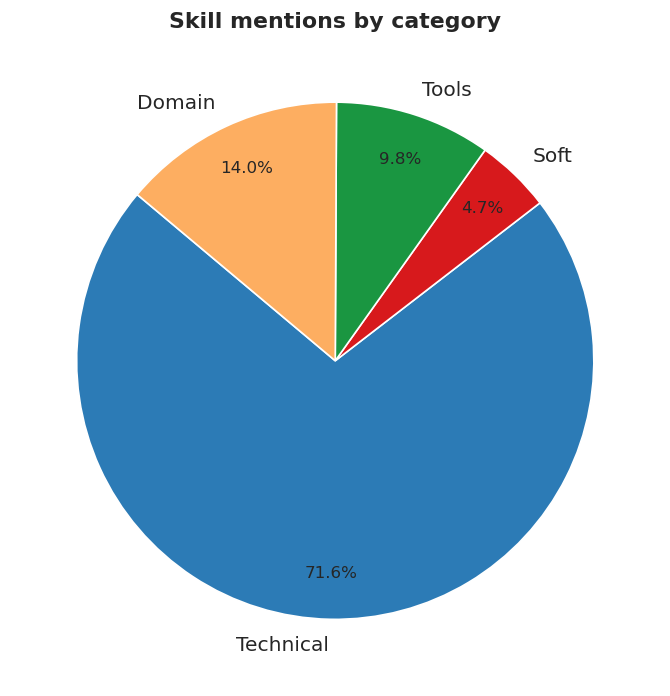

In [10]:
# ── Skill share pie (category totals) ──
cat_totals = {
    'Technical': sum(tech_counter.values()),
    'Soft':      sum(soft_counter.values()),
    'Tools':     sum(tool_counter.values()),
    'Domain':    sum(domain_counter.values()),
}
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    cat_totals.values(),
    labels=cat_totals.keys(),
    autopct='%1.1f%%',
    colors=['#2c7bb6', '#d7191c', '#1a9641', '#fdae61'],
    startangle=140,
    pctdistance=0.82,
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title('Skill mentions by category', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Q2 — Job Complexity (number of required skills)

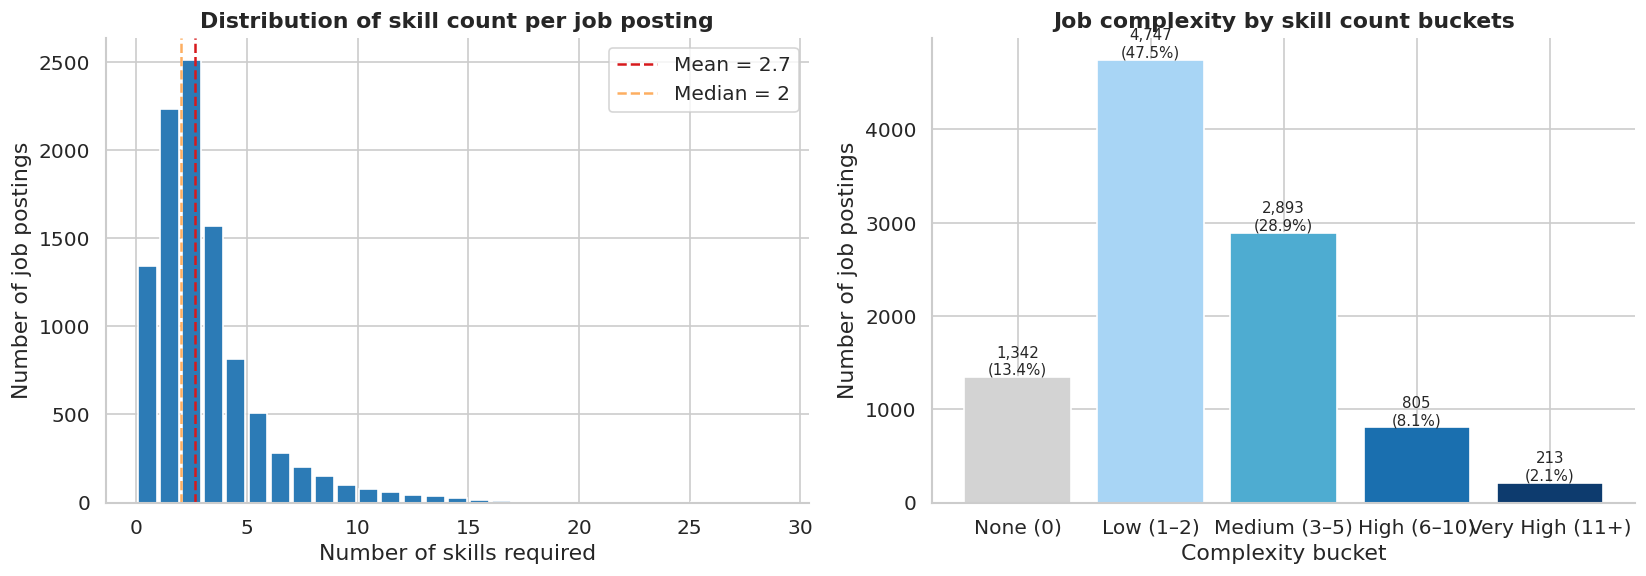

In [11]:
# ── Distribution histogram ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['skill_count'], bins=range(0, df['skill_count'].max() + 2),
             color='#2c7bb6', edgecolor='white', rwidth=0.85)
axes[0].set_xlabel('Number of skills required')
axes[0].set_ylabel('Number of job postings')
axes[0].set_title('Distribution of skill count per job posting', fontweight='bold')
axes[0].axvline(df['skill_count'].mean(), color='#d7191c', linestyle='--', linewidth=1.5,
                label=f"Mean = {df['skill_count'].mean():.1f}")
axes[0].axvline(df['skill_count'].median(), color='#fdae61', linestyle='--', linewidth=1.5,
                label=f"Median = {df['skill_count'].median():.0f}")
axes[0].legend()
sns.despine(ax=axes[0])

# Complexity buckets
def bucket(n):
    if n == 0:  return 'None (0)'
    if n <= 2:  return 'Low (1–2)'
    if n <= 5:  return 'Medium (3–5)'
    if n <= 10: return 'High (6–10)'
    return 'Very High (11+)'

df['complexity'] = df['skill_count'].apply(bucket)
order = ['None (0)', 'Low (1–2)', 'Medium (3–5)', 'High (6–10)', 'Very High (11+)']
complexity_counts = df['complexity'].value_counts().reindex(order)

palette2 = ['#d3d3d3', '#a8d5f5', '#4eacd1', '#1a6faf', '#0d3b6e']
axes[1].bar(order, complexity_counts, color=palette2, edgecolor='white')
for i, v in enumerate(complexity_counts):
    axes[1].text(i, v + 30, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[1].set_xlabel('Complexity bucket')
axes[1].set_ylabel('Number of job postings')
axes[1].set_title('Job complexity by skill count buckets', fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

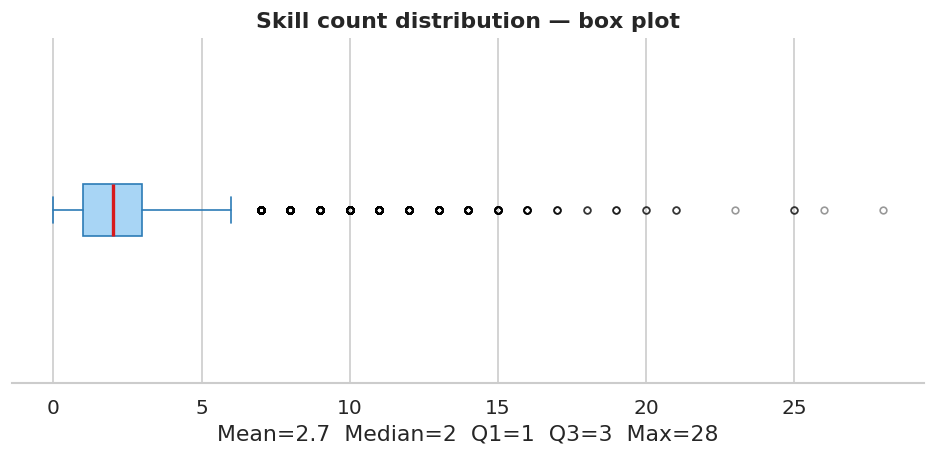

In [12]:
# ── Box plot of skill count ──
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(df['skill_count'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='#a8d5f5', color='#2c7bb6'),
           medianprops=dict(color='#d7191c', linewidth=2),
           whiskerprops=dict(color='#2c7bb6'),
           capprops=dict(color='#2c7bb6'),
           flierprops=dict(marker='o', color='#fdae61', alpha=0.4, markersize=4))
ax.set_xlabel('Number of skills')
ax.set_yticks([])
ax.set_title('Skill count distribution — box plot', fontweight='bold')
stats = df['skill_count'].describe()
info = f"Mean={stats['mean']:.1f}  Median={stats['50%']:.0f}  "\
       f"Q1={stats['25%']:.0f}  Q3={stats['75%']:.0f}  Max={stats['max']:.0f}"
ax.set_xlabel(info)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

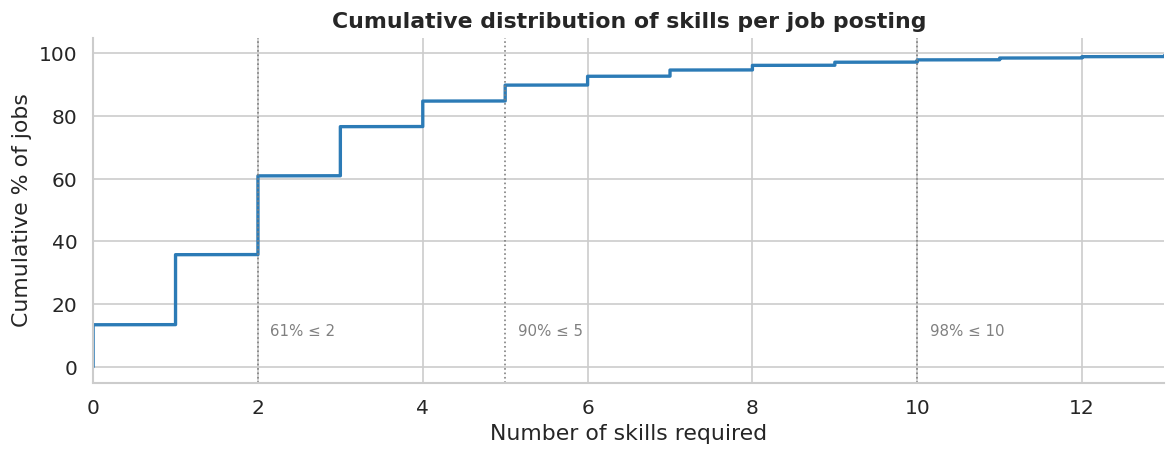

In [13]:
# ── CDF — cumulative % of jobs covered by skill count threshold ──
sorted_counts = np.sort(df['skill_count'])
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sorted_counts, cdf, color='#2c7bb6', linewidth=2)
for threshold in [2, 5, 10]:
    pct = (df['skill_count'] <= threshold).mean() * 100
    ax.axvline(threshold, linestyle=':', color='gray', linewidth=1)
    ax.text(threshold + 0.15, 10, f'{pct:.0f}% ≤ {threshold}', fontsize=9, color='gray')
ax.set_xlabel('Number of skills required')
ax.set_ylabel('Cumulative % of jobs')
ax.set_title('Cumulative distribution of skills per job posting', fontweight='bold')
ax.set_xlim(0, df['skill_count'].quantile(0.99))
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 5. Q3 — Skill Co-occurrence

In [14]:
# Build co-occurrence counter
co = defaultdict(Counter)
for cell in df['all_skills'].dropna():
    skills = [s.strip().lower() for s in str(cell).split(';') if s.strip()]
    for i, s1 in enumerate(skills):
        for s2 in skills[i+1:]:
            co[s1][s2] += 1
            co[s2][s1] += 1

# Flatten to dataframe
pairs = []
for s1, partners in co.items():
    for s2, cnt in partners.items():
        if s1 < s2:
            pairs.append({'skill_a': s1, 'skill_b': s2, 'count': cnt})
co_df = pd.DataFrame(pairs).sort_values('count', ascending=False).reset_index(drop=True)
print(f'Total unique pairs: {len(co_df):,}')
co_df.head(20)

Total unique pairs: 30,861


,skill_a,skill_b,count
0,java,kotlin,186
1,javascript,typescript,159
2,css,html,158
3,angular,javascript,128
4,node.js,typescript,125
5,automation,qa,114
6,html,javascript,108
7,angular,typescript,106
8,javascript,node.js,101
9,css,javascript,100


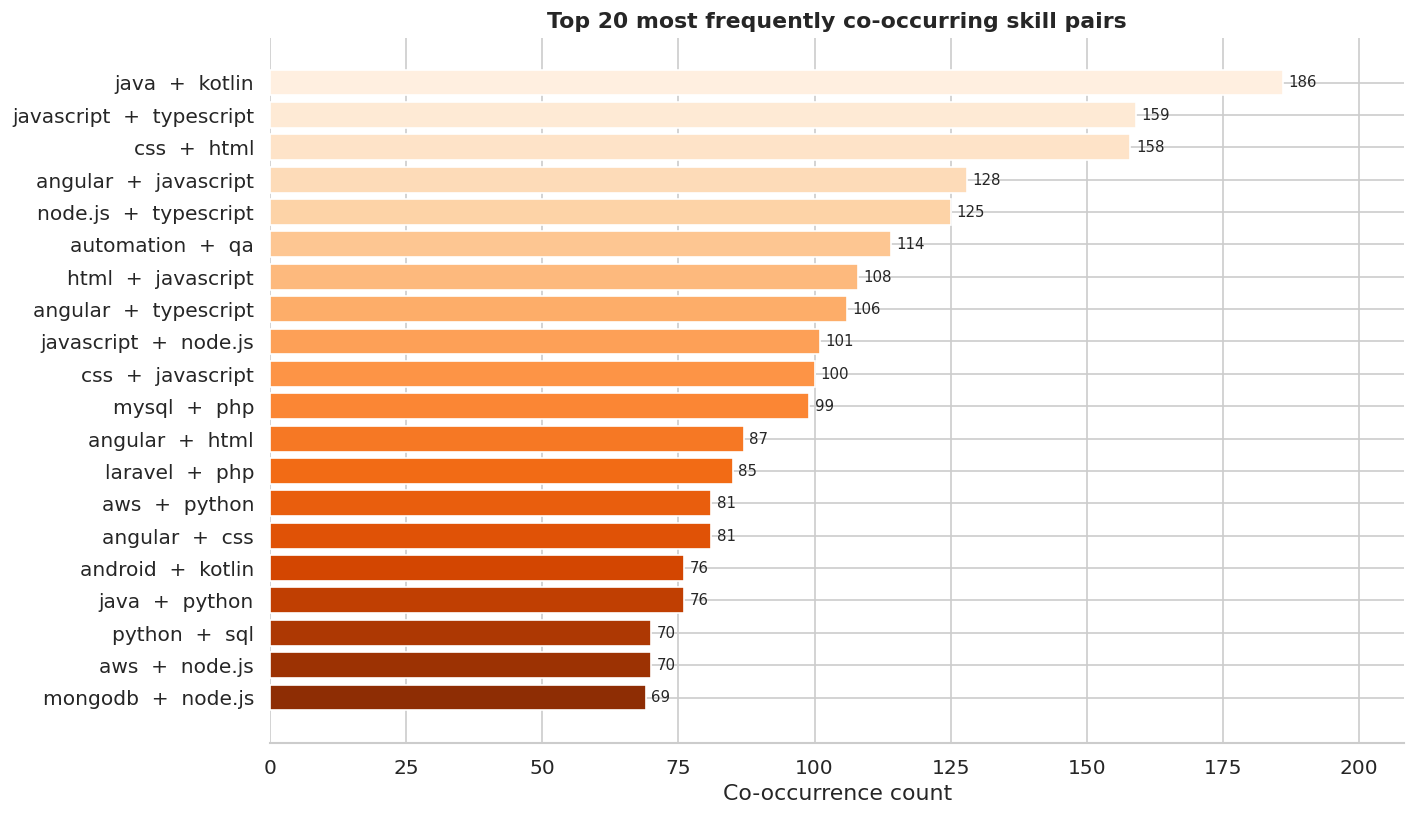

In [15]:
# ── Top 20 co-occurring pairs bar chart ──
top_pairs = co_df.head(20).copy()
top_pairs['pair'] = top_pairs['skill_a'] + '  +  ' + top_pairs['skill_b']

fig, ax = plt.subplots(figsize=(12, 7))
palette3 = sns.color_palette('Oranges_r', n_colors=20)
bars = ax.barh(top_pairs['pair'][::-1], top_pairs['count'][::-1], color=palette3)
for bar, val in zip(bars, top_pairs['count'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9)
ax.set_xlabel('Co-occurrence count')
ax.set_title('Top 20 most frequently co-occurring skill pairs', fontweight='bold')
ax.set_xlim(0, top_pairs['count'].max() * 1.12)
sns.despine(left=True)
plt.tight_layout()
plt.show()

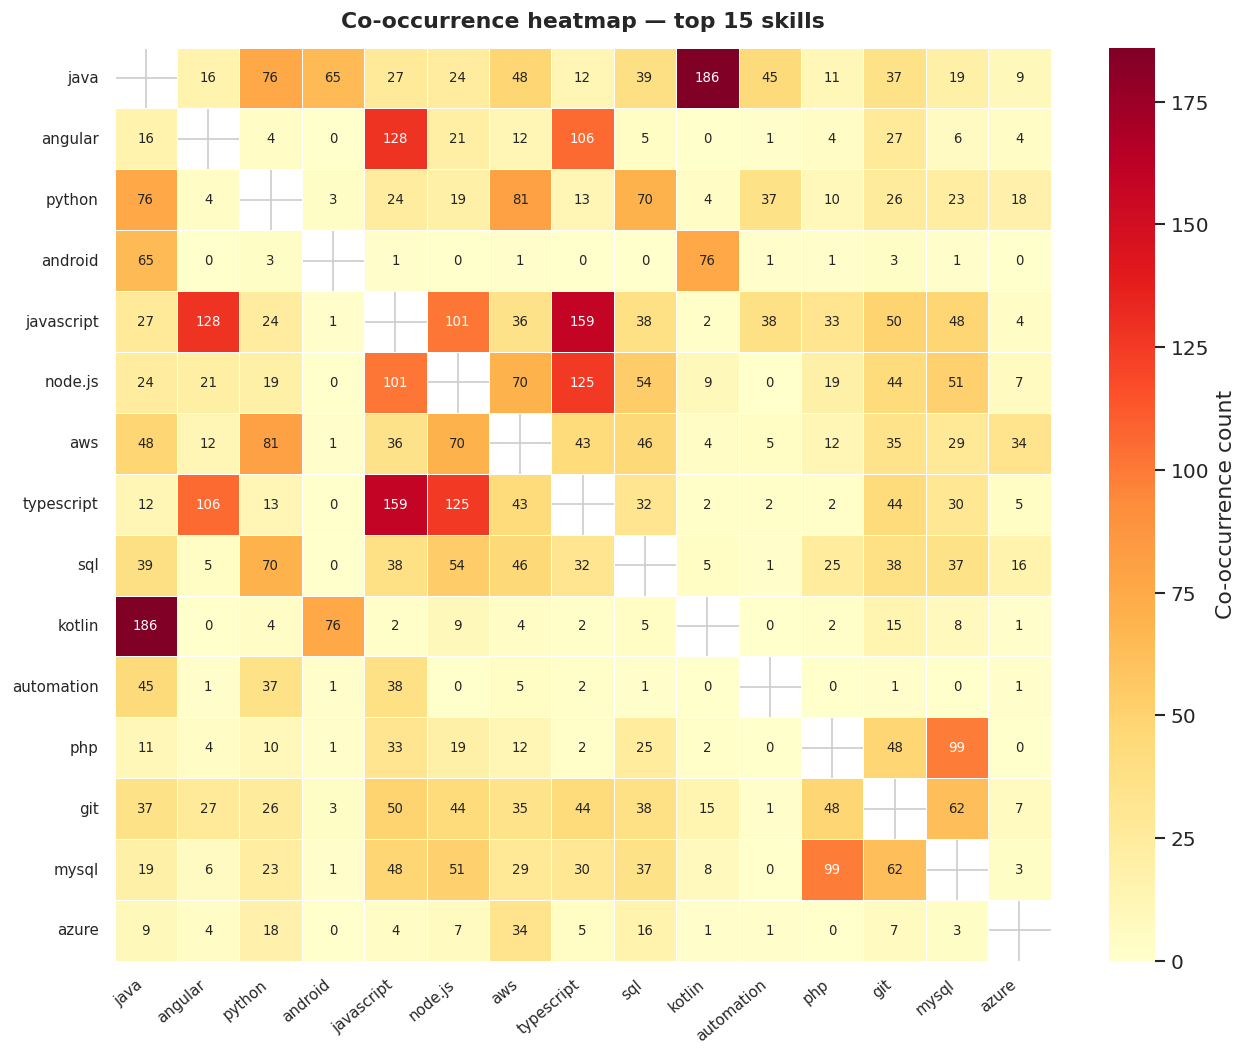

In [16]:
# ── Co-occurrence heatmap for top-N skills ──
TOP_N = 15
top_skills = [sk for sk, _ in all_skills_counter.most_common(TOP_N)]

matrix = pd.DataFrame(0, index=top_skills, columns=top_skills)
for _, row in co_df.iterrows():
    a, b, cnt = row['skill_a'], row['skill_b'], row['count']
    if a in top_skills and b in top_skills:
        matrix.loc[a, b] = cnt
        matrix.loc[b, a] = cnt

mask = np.eye(TOP_N, dtype=bool)  # hide diagonal

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    matrix, mask=mask, ax=ax,
    cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5,
    cbar_kws={'label': 'Co-occurrence count'},
    annot_kws={'size': 8}
)
ax.set_title(f'Co-occurrence heatmap — top {TOP_N} skills', fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

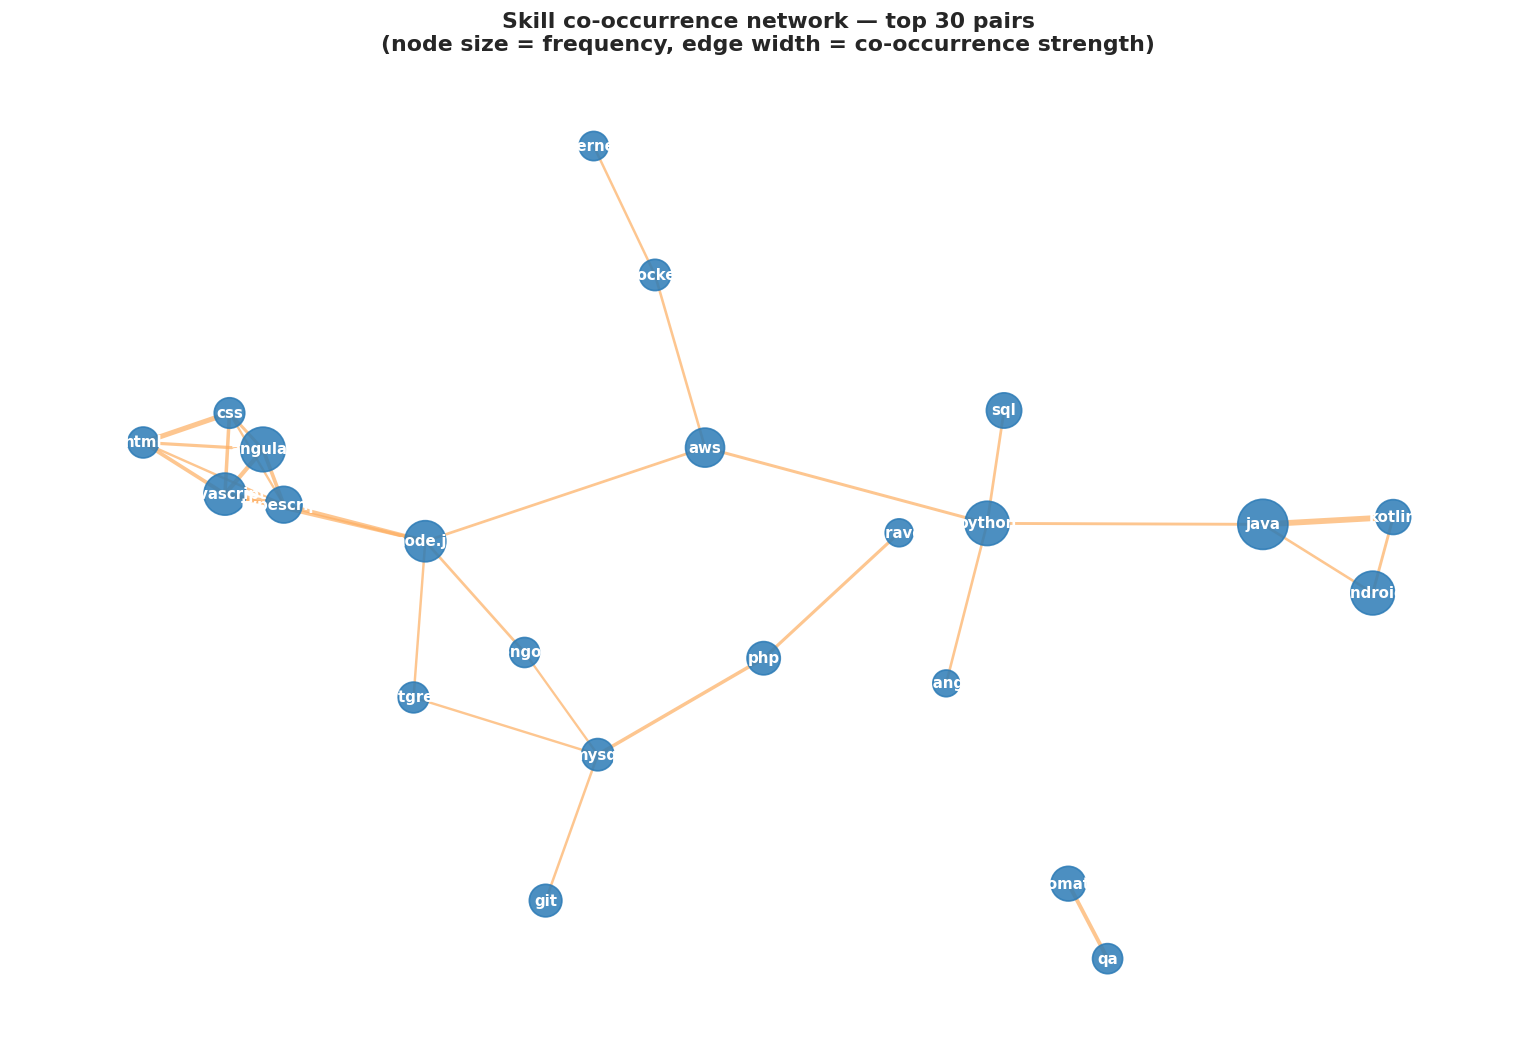

In [17]:
# ── Network graph of skill co-occurrences (top pairs) ──
try:
    import networkx as nx
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'networkx', '-q'])
    import networkx as nx

# Keep top-30 pairs and skills that appear in them
N_PAIRS = 30
top_net = co_df.head(N_PAIRS)

G = nx.Graph()
for _, row in top_net.iterrows():
    G.add_edge(row['skill_a'], row['skill_b'], weight=row['count'])

# Node size ~ frequency; edge width ~ co-occurrence
node_sizes = [all_skills_counter.get(n, 1) * 0.8 + 200 for n in G.nodes()]
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_w = max(edge_weights)
edge_widths = [3 * w / max_w + 0.5 for w in edge_weights]

pos = nx.spring_layout(G, seed=42, k=1.8)

fig, ax = plt.subplots(figsize=(13, 9))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color='#2c7bb6', alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, width=edge_widths,
                       edge_color='#fdae61', alpha=0.7, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white',
                        font_weight='bold', ax=ax)
ax.set_title(f'Skill co-occurrence network — top {N_PAIRS} pairs\n'
             '(node size = frequency, edge width = co-occurrence strength)',
             fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Bonus — Job Title Word Cloud

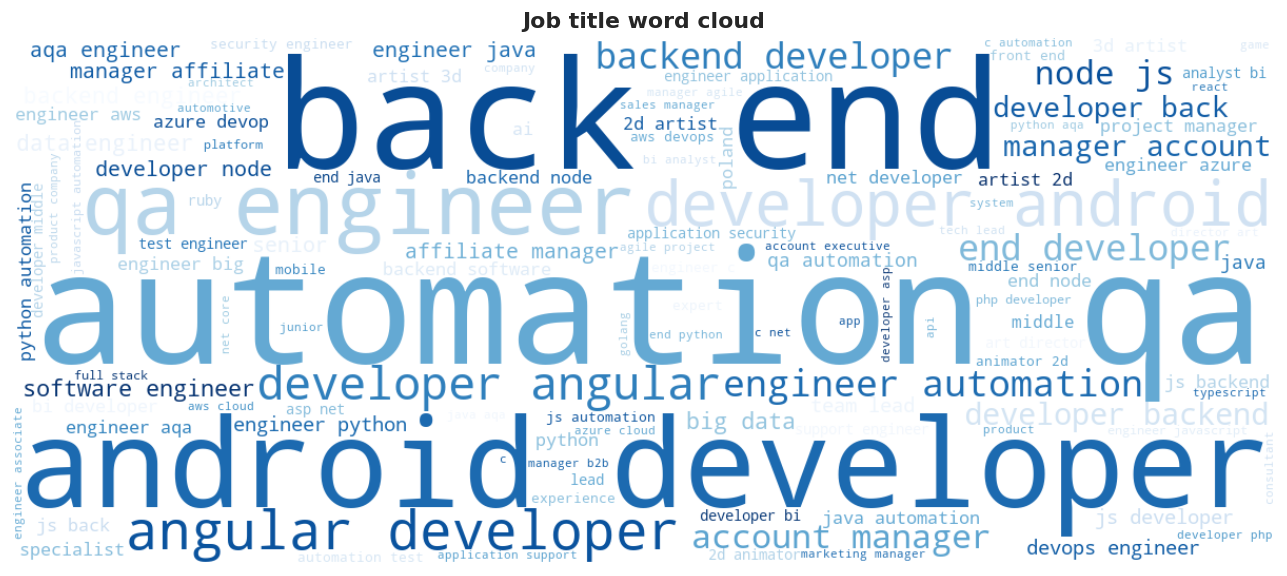

In [18]:
try:
    from wordcloud import WordCloud
    HAVE_WC = True
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud
    HAVE_WC = True

text = ' '.join(df['title'].dropna().str.lower())
wc = WordCloud(width=1200, height=500, background_color='white',
               colormap='Blues', max_words=120,
               stopwords={'and','the','of','for','in','to','a','with','or',
                          'on','at','an','is','as','by','mid'}).generate(text)

fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Job title word cloud', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Summary Statistics

In [19]:
print('=== Dataset Overview ===')
print(f'Total job postings:          {len(df):,}')
print(f'Unique skills (all_skills):  {len(all_skills_counter):,}')
print(f'Avg skills per posting:      {df["skill_count"].mean():.2f}')
print(f'Median skills per posting:   {df["skill_count"].median():.0f}')
print(f'Max skills in one posting:   {df["skill_count"].max()}')
print(f'Jobs with 0 skills:          {(df["skill_count"]==0).sum():,} '
      f'({(df["skill_count"]==0).mean()*100:.1f}%)')
print()
print('=== Top 5 skills overall ===')
for sk, cnt in all_skills_counter.most_common(5):
    print(f'  {sk:<25} {cnt:>5} postings')
print()
print('=== Top 5 co-occurring pairs ===')
for _, row in co_df.head(5).iterrows():
    print(f'  {row["skill_a"]} + {row["skill_b"]}: {row["count"]}')

=== Dataset Overview ===
Total job postings:          10,000
Unique skills (all_skills):  5,012
Avg skills per posting:      2.66
Median skills per posting:   2
Max skills in one posting:   28
Jobs with 0 skills:          1,342 (13.4%)

=== Top 5 skills overall ===
  java                        881 postings
  angular                     645 postings
  python                      633 postings
  android                     613 postings
  javascript                  546 postings

=== Top 5 co-occurring pairs ===
  java + kotlin: 186
  javascript + typescript: 159
  css + html: 158
  angular + javascript: 128
  node.js + typescript: 125
